#Setup ⬇️⬇️⬇️

In [51]:
print("RetailSense")
#Imports
import pandas as pd
import numpy as np
import sqlite3
import json
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import plotly.express as px
import plotly.graph_objects as go
import requests
import pprint
import utils

print()
print("✅ Import Successful ✅")

# Version Confirmation
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"sqlite3 engine version: {sqlite3.sqlite_version}")
print(f"matplotlib version: {plt.matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"plotly version: {px.pd_version.version if hasattr(px, 'pd_version') else 'Installed'}")
print(f"requests version: {requests.__version__}")

RetailSense

✅ Import Successful ✅
pandas version: 2.2.2
numpy version: 2.0.2
sqlite3 engine version: 3.37.2
matplotlib version: 3.10.0
seaborn version: 0.13.2
plotly version: Installed
requests version: 2.32.4


In [52]:
# run_once_generate_data.py
import pandas as pd
import numpy as np
import random
import os

np.random.seed(42)
random.seed(42)
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# --- Customers ---
n_customers = 500
cities = ["Mumbai", "Delhi", "Bengaluru", "Hyderabad", "Chennai", "Pune", "Kolkata"]
genders = ["M", "F", "Other"]

ages = np.random.randint(18, 65, n_customers).astype(float)
ages[np.random.choice(n_customers, 40, replace=False)] = np.nan  # inject nulls

gender_list = [random.choice(genders) for _ in range(n_customers)]
for i in np.random.choice(n_customers, 30, replace=False):
    gender_list[i] = None  # inject nulls

customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "name": [f"Customer_{i}" for i in range(1, n_customers + 1)],
    "email": [f"user{i}@example.com" for i in range(1, n_customers + 1)],
    "age": ages,
    "city": [random.choice(cities) for _ in range(n_customers)],
    "gender": gender_list,
    "signup_date": pd.date_range("2022-01-01", periods=n_customers, freq="D").strftime("%Y-%m-%d").tolist()
})

# Add 10 duplicate emails
for i in range(10):
    customers.iloc[-(i+1), customers.columns.get_loc("email")] = customers.iloc[i]["email"]

customers.to_csv("data/customers.csv", index=False)
print("customers.csv created:", customers.shape)

# --- Products ---
categories = ["Electronics", "Clothing", "Food", "Books"]
n_products = 80

prices = np.random.randint(200, 5000, n_products).astype(float)
ratings = np.random.uniform(1.5, 5.0, n_products).round(1)
ratings[np.random.choice(n_products, 12, replace=False)] = np.nan

# Make some prices into dirty strings
price_list = []
for p in prices:
    r = random.random()
    if r < 0.2:
        price_list.append(f"₹{int(p)}")
    elif r < 0.35:
        price_list.append(str(float(p)))
    else:
        price_list.append(p)

products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, n_products + 1)],
    "product_name": [f"Product_{i}" for i in range(1, n_products + 1)],
    "category": [random.choice(categories) for _ in range(n_products)],
    "price": price_list,
    "rating": ratings
})
products.to_csv("data/products.csv", index=False)
print("products.csv created:", products.shape)

# --- Orders ---
n_orders = 1500
orders = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": [random.choice(customers["customer_id"].tolist()) for _ in range(n_orders)],
    "product_id": [random.choice(products["product_id"].tolist()) for _ in range(n_orders)],
    "order_date": pd.date_range("2024-01-01", periods=n_orders, freq="H").strftime("%Y-%m-%d").tolist(),
    "quantity": np.random.randint(1, 6, n_orders),
    "discount_pct": np.random.choice([0, 5, 10, 15, 20, 25, 30, 40], n_orders)
})
orders.to_csv("data/orders.csv", index=False)
print("orders.csv created:", orders.shape)

print("\n✅ All datasets created in /data folder.")


customers.csv created: (500, 7)
products.csv created: (80, 5)
orders.csv created: (1500, 6)

✅ All datasets created in /data folder.


/tmp/ipykernel_8151/4285408729.py:76: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



#Data Cleaning with Pandas ⬇️⬇️⬇️

In [53]:
#Load all three CSVs
customers_df = pd.read_csv("data/customers.csv")
orders_df = pd.read_csv("data/orders.csv")
products_df = pd.read_csv("data/products.csv")
print("="*60)
print(customers_df)
print("="*60)
print(orders_df)
print("="*60)
print(products_df)
print("="*60)


    customer_id          name              email   age       city gender  \
0         C0001    Customer_1  user1@example.com  56.0     Mumbai  Other   
1         C0002    Customer_2  user2@example.com  46.0  Hyderabad      M   
2         C0003    Customer_3  user3@example.com  32.0    Kolkata      M   
3         C0004    Customer_4  user4@example.com  60.0     Mumbai  Other   
4         C0005    Customer_5  user5@example.com  25.0    Kolkata      F   
..          ...           ...                ...   ...        ...    ...   
495       C0496  Customer_496  user5@example.com  37.0    Chennai  Other   
496       C0497  Customer_497  user4@example.com  41.0    Chennai      M   
497       C0498  Customer_498  user3@example.com  29.0  Bengaluru    NaN   
498       C0499  Customer_499  user2@example.com  52.0  Hyderabad    NaN   
499       C0500  Customer_500  user1@example.com  50.0       Pune  Other   

    signup_date  
0    2022-01-01  
1    2022-01-02  
2    2022-01-03  
3    2022-01-04

In [54]:
#For each DataFrame, run: .shape, .info(), .describe(), .isnull().sum()
print("="*60)
print("For Customers Dataframe ⬇️⬇️⬇️")
print()
print("Shape:-",customers_df.shape)
print()
print("Info:-")
customers_df.info()
print()
print("Describe:-\n",customers_df.describe())
print()
print("Nulls:-\n",customers_df.isna().sum())
print("="*60)
print("="*60)
print("For Orders Dataframe ⬇️⬇️⬇️")
print()
print("Shape:-",orders_df.shape)
print()
print("Info:-")
orders_df.info()
print()
print("Describe:-\n",orders_df.describe())
print()
print("Nulls:-\n",orders_df.isna().sum())
print("="*60)
print("="*60)
print("For Products Dataframe ⬇️⬇️⬇️")
print()
print("Shape:-",products_df.shape)
print()
print("Info:-")
products_df.info()
print()
print("Describe:-\n",products_df.describe())
print()
print("Nulls:-\n",products_df.isna().sum())
print("="*60)

For Customers Dataframe ⬇️⬇️⬇️

Shape:- (500, 7)

Info:-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  500 non-null    object 
 1   name         500 non-null    object 
 2   email        500 non-null    object 
 3   age          460 non-null    float64
 4   city         500 non-null    object 
 5   gender       470 non-null    object 
 6   signup_date  500 non-null    object 
dtypes: float64(1), object(6)
memory usage: 27.5+ KB

Describe:-
               age
count  460.000000
mean    41.245652
std     13.312667
min     18.000000
25%     30.750000
50%     42.000000
75%     52.000000
max     64.000000

Nulls:-
 customer_id     0
name            0
email           0
age            40
city            0
gender         30
signup_date     0
dtype: int64
For Orders Dataframe ⬇️⬇️⬇️

Shape:- (1500, 6)

Info:-
<class 'pandas.core.frame.Dat

# 📋 Data Quality & Schema Audit Summary
## 1) Customers DataFrame (500 rows, 7 columns)
### -> Missing values Found:
1) age: 40 Nulls
2) gender: 30 Nulls

### -> DataType Issues:
1) age: Currently stored as float64 due to the presence of NaN values. It should ideally be cast to an integer type (Int64 with capital 'I' to support missing values) after handling data cleaning.

2) signup_date: Stored as a generic object (string). It must be converted to datetime64[ns] for chronological sorting or time-series analysis.

### -> Statistical Insights:
1) The customer base ranges from 18 to 64 years old.
2) The average customer age is roughly 41 years old.

## 2) Orders DataFrame (1500 rows, 6 columns)
### -> Missing values Found:
0 missing values. This dataset is completely clean of null entries.

### -> DataType Issues:
1) order_date: Stored as a generic object (string). It must be converted to datetime64[ns] to calculate metrics like order frequency or cohort retention.

### -> Statistical Insights:
1) quantity: Customers purchase between 1 and 5 items per order item entry, averaging around 3 items.
2) discount_pct: Discounts range from 0% to 40%, with an average discount rate of 17.6%.

## 3) Products Dataframe (80 rows, 5 columns)
### -> Missing Values Found:
1) rating: 12 Nulls

### -> DataType Issues:
1) price: Critical Error. Stored as an object (string) instead of a numeric type (float64). This indicates the presence of non-numeric characters (like currency symbols $, commas ,, or text) blocking calculations. It requires string stripping and type casting.

### -> Statistical Insights:
1) Product ratings vary wildly from a low 1.5 to a perfect 5.0.
2) The median rating sits at 3.35, indicating a slightly below-average sentiment for products overall.

#=================================================================

In [55]:
#Clean customers.csv
#Fill null age values with the median age
customers_df["age"] = customers_df["age"].fillna(customers_df["age"].median())
#Fill null gender values with "Unknown"
customers_df["gender"] = customers_df["gender"].fillna("Unknown")
#Check for and remove duplicate emails (keep the first occurrence)
customers_df.drop_duplicates(subset=["email"], keep="first")
#Convert gender column to category dtype
customers_df["gender"] = customers_df["gender"].astype("category")
#Add a new column age_group using your classify_customer() function from utils.py
age_category=[]
for age in customers_df["age"]:
  seg = utils.classify_customer(age)
  age_category.append(seg)
customers_df["age_group"] = age_category
#Save the cleaned result to outputs/cleaned_customers.csv
customers_df.to_csv('outputs/cleaned_customers.csv', index=False)
print(customers_df)

    customer_id          name              email   age       city   gender  \
0         C0001    Customer_1  user1@example.com  56.0     Mumbai    Other   
1         C0002    Customer_2  user2@example.com  46.0  Hyderabad        M   
2         C0003    Customer_3  user3@example.com  32.0    Kolkata        M   
3         C0004    Customer_4  user4@example.com  60.0     Mumbai    Other   
4         C0005    Customer_5  user5@example.com  25.0    Kolkata        F   
..          ...           ...                ...   ...        ...      ...   
495       C0496  Customer_496  user5@example.com  37.0    Chennai    Other   
496       C0497  Customer_497  user4@example.com  41.0    Chennai        M   
497       C0498  Customer_498  user3@example.com  29.0  Bengaluru  Unknown   
498       C0499  Customer_499  user2@example.com  52.0  Hyderabad  Unknown   
499       C0500  Customer_500  user1@example.com  50.0       Pune    Other   

    signup_date age_group  
0    2022-01-01    Senior  
1    20

In [56]:
#Clean products.csv
#The price column is stored as a string (e.g., "₹1200" or "1200.0"). Fix it so it becomes a proper float.
products_df["price"] = products_df["price"].astype("string").str.replace("₹", "", regex=False).astype("float64")
#Fill null rating values with the mean rating (rounded to 1 decimal)
products_df["rating"] = products_df["rating"].fillna(products_df["rating"].mean().round(1))
#Convert category to category dtype
products_df["category"] = products_df["category"].astype("category")
print(products_df)

   product_id product_name     category   price  rating
0        P001    Product_1     Clothing  1013.0     3.2
1        P002    Product_2        Books  4324.0     1.7
2        P003    Product_3  Electronics  2232.0     4.5
3        P004    Product_4     Clothing  4772.0     1.6
4        P005    Product_5     Clothing  4613.0     2.7
..        ...          ...          ...     ...     ...
75       P076   Product_76  Electronics  3881.0     4.5
76       P077   Product_77     Clothing  1490.0     5.0
77       P078   Product_78     Clothing  1840.0     3.9
78       P079   Product_79         Food  2882.0     3.1
79       P080   Product_80  Electronics  1187.0     3.8

[80 rows x 5 columns]


In [57]:
#Null Report Function
#Write a function (in the notebook, not utils.py) called null_report(df, name) that takes a DataFrame and its name, and prints a clean summary
def null_report(df, name):
  null_count = df.isna().sum()
  print(f"=== Null Report: {name} ===")
  for col in null_count.index:
    if null_count[col]>0:
      print(f"{col}      -> {null_count[col]} Nulls   ({(null_count[col]/ len(df)) * 100})%")
null_report(customers_df, "Customer")
null_report(orders_df, "Customer")
null_report(products, "Customer")

=== Null Report: Customer ===
=== Null Report: Customer ===
=== Null Report: Customer ===
rating      -> 12 Nulls   (15.0)%


#NumPy Analysis ⬇️⬇️⬇️


In [58]:
#Revenue Array
price = np.array(products_df["price"])
price_with_tax = price * 1.18
final_price = price_with_tax * 0.90
print("Shape:-",final_price.shape)
print("DataType:-",final_price.dtype)
print("Final Price (first 5):-",final_price[:5])

Shape:- (80,)
DataType:- float64
Final Price (first 5):- [1075.806 4592.088 2370.384 5067.864 4899.006]


In [59]:
#Reshape Exercise
print("="*60)
price_first_20 = final_price[:20]
print("First 20 Product Prices:-\n",price_first_20)
print(price_first_20.shape)
print("="*60)
reshaped_price = price_first_20.reshape(4,5)
print("Reshaped Price:-\n",reshaped_price)
print(reshaped_price.shape)
print("="*60)
transposed_price = reshaped_price.T
print("Transposed Price:-\n",transposed_price)
print(transposed_price.shape)
print("="*60)
flattened_price = transposed_price.flatten()
print("Flattened Price:-\n",flattened_price)
print(flattened_price.shape)
print("="*60)

First 20 Product Prices:-
 [1075.806 4592.088 2370.384 5067.864 4899.006  471.528 5301.504  500.202
 3941.082 2093.202 1552.644 2786.688 4843.782 1189.44  3855.06  4922.37
 4974.408 2999.088 4205.52  2389.5  ]
(20,)
Reshaped Price:-
 [[1075.806 4592.088 2370.384 5067.864 4899.006]
 [ 471.528 5301.504  500.202 3941.082 2093.202]
 [1552.644 2786.688 4843.782 1189.44  3855.06 ]
 [4922.37  4974.408 2999.088 4205.52  2389.5  ]]
(4, 5)
Transposed Price:-
 [[1075.806  471.528 1552.644 4922.37 ]
 [4592.088 5301.504 2786.688 4974.408]
 [2370.384  500.202 4843.782 2999.088]
 [5067.864 3941.082 1189.44  4205.52 ]
 [4899.006 2093.202 3855.06  2389.5  ]]
(5, 4)
Flattened Price:-
 [1075.806  471.528 1552.644 4922.37  4592.088 5301.504 2786.688 4974.408
 2370.384  500.202 4843.782 2999.088 5067.864 3941.082 1189.44  4205.52
 4899.006 2093.202 3855.06  2389.5  ]
(20,)


#SQL Analysis ⬇️⬇️⬇️

In [60]:
#Create the Database
import sqlite3
import pandas as pd

conn = sqlite3.connect("outputs/retailsense.db")

# Write your cleaned DataFrames to the database
customers_df.to_sql("customers", conn, if_exists="replace", index=False)
products_df.to_sql("products", conn, if_exists="replace", index=False)
orders_df.to_sql("orders", conn, if_exists="replace", index=False)

1500

In [61]:
query = '''
SELECT * FROM customers
'''
print(pd.read_sql_query(query, conn))

    customer_id          name              email   age       city   gender  \
0         C0001    Customer_1  user1@example.com  56.0     Mumbai    Other   
1         C0002    Customer_2  user2@example.com  46.0  Hyderabad        M   
2         C0003    Customer_3  user3@example.com  32.0    Kolkata        M   
3         C0004    Customer_4  user4@example.com  60.0     Mumbai    Other   
4         C0005    Customer_5  user5@example.com  25.0    Kolkata        F   
..          ...           ...                ...   ...        ...      ...   
495       C0496  Customer_496  user5@example.com  37.0    Chennai    Other   
496       C0497  Customer_497  user4@example.com  41.0    Chennai        M   
497       C0498  Customer_498  user3@example.com  29.0  Bengaluru  Unknown   
498       C0499  Customer_499  user2@example.com  52.0  Hyderabad  Unknown   
499       C0500  Customer_500  user1@example.com  50.0       Pune    Other   

    signup_date age_group  
0    2022-01-01    Senior  
1    20

In [62]:
#How many customers are from each city? Sort by count descending.
query = '''
SELECT city, COUNT(name) as No_of_Customers FROM customers
GROUP BY city
ORDER BY COUNT(name) DESC
'''
result = pd.read_sql_query(query, conn)
print(result)

        city  No_of_Customers
0  Hyderabad               88
1       Pune               76
2    Kolkata               76
3  Bengaluru               70
4    Chennai               67
5      Delhi               65
6     Mumbai               58


In [63]:
#What are the top 5 most expensive products? Show product name and price.
query = '''
SELECT product_name, price FROM products
ORDER BY price DESC
LIMIT 5
'''
result = pd.read_sql_query(query, conn)
print(result)

  product_name   price
0    Product_7  4992.0
1   Product_73  4875.0
2    Product_4  4772.0
3   Product_30  4694.0
4   Product_17  4684.0


In [64]:
#Which orders had a discount greater than 20%? Show order_id, customer_id, discount_pct.
query = '''
SELECT order_id, customer_id, discount_pct FROM orders
WHERE discount_pct>20
'''
result = pd.read_sql_query(query, conn)
print(result)

    order_id customer_id  discount_pct
0     O00002       C0209            25
1     O00005       C0431            30
2     O00010       C0061            40
3     O00016       C0367            25
4     O00017       C0150            30
..       ...         ...           ...
528   O01492       C0496            30
529   O01495       C0342            40
530   O01498       C0034            30
531   O01499       C0282            25
532   O01500       C0278            40

[533 rows x 3 columns]


In [65]:
#What is the average rating per product category?
query = '''
SELECT category, AVG(rating) as avg_rating FROM products
GROUP BY category
'''
result = pd.read_sql_query(query, conn)
print(result)

      category  avg_rating
0        Books    3.279167
1     Clothing    3.392857
2  Electronics    3.409524
3         Food    3.133333


In [66]:
#Which categories have more than 10 products AND average rating above 3.5?
query = '''
SELECT category, COUNT(product_id) as no_of_products, AVG(rating) as avg_rating FROM products
GROUP BY category
HAVING COUNT(product_id)>10 AND AVG(rating)>3.5
'''
result = pd.read_sql_query(query, conn)
print(result)

Empty DataFrame
Columns: [category, no_of_products, avg_rating]
Index: []


In [67]:
#For each order, show the customer name, product name, quantity, and base price.
query = '''
SELECT o.order_id, c.name, p.product_name, o.quantity, p.price
FROM orders as o
INNER JOIN products as p
ON o.product_id = p.product_id
INNER JOIN customers as c
ON c.customer_id = o.customer_id
'''
result = pd.read_sql_query(query, conn)
print(result)

     order_id          name product_name  quantity   price
0      O00001  Customer_283   Product_38         1  1006.0
1      O00002  Customer_209   Product_39         4  1663.0
2      O00003   Customer_48   Product_21         5  3700.0
3      O00004  Customer_116   Product_23         5   575.0
4      O00005  Customer_431   Product_47         2  4521.0
...       ...           ...          ...       ...     ...
1495   O01496  Customer_178   Product_48         5  1024.0
1496   O01497  Customer_364   Product_76         1  3881.0
1497   O01498   Customer_34   Product_64         1  1049.0
1498   O01499  Customer_282   Product_26         5  4588.0
1499   O01500  Customer_278   Product_70         2  2230.0

[1500 rows x 5 columns]


In [68]:
#	Which customers have placed no orders? Show their names and emails.
query = '''
SELECT c.name, c.email
FROM customers as c
LEFT JOIN orders as o
ON o.customer_id = c.customer_id
WHERE o.quantity IS NULL
'''
result = pd.read_sql_query(query, conn)
print(result)

            name                email
0     Customer_6    user6@example.com
1     Customer_7    user7@example.com
2    Customer_58   user58@example.com
3    Customer_92   user92@example.com
4    Customer_95   user95@example.com
5   Customer_101  user101@example.com
6   Customer_108  user108@example.com
7   Customer_133  user133@example.com
8   Customer_138  user138@example.com
9   Customer_139  user139@example.com
10  Customer_202  user202@example.com
11  Customer_207  user207@example.com
12  Customer_245  user245@example.com
13  Customer_292  user292@example.com
14  Customer_323  user323@example.com
15  Customer_335  user335@example.com
16  Customer_353  user353@example.com
17  Customer_378  user378@example.com
18  Customer_432  user432@example.com
19  Customer_457  user457@example.com
20  Customer_458  user458@example.com
21  Customer_460  user460@example.com
22  Customer_475  user475@example.com
23  Customer_480  user480@example.com


#Advanced Pandas: GroupBy & Pivot ⬇️⬇️⬇️

In [69]:
#Merge DataFrames
merged_df = pd.merge(orders_df, customers_df, on="customer_id", how="inner")
full_df = pd.merge(merged_df, products_df, on="product_id", how="inner")
full_df["revenue"] = utils.calculate_revenue(full_df["price"], full_df["quantity"], full_df['discount_pct'])
print(full_df)

     order_id customer_id product_id  order_date  quantity  discount_pct  \
0      O00001       C0283       P038  2024-01-01         1            20   
1      O00002       C0209       P039  2024-01-01         4            25   
2      O00003       C0048       P021  2024-01-01         5            20   
3      O00004       C0116       P023  2024-01-01         5            10   
4      O00005       C0431       P047  2024-01-01         2            30   
...       ...         ...        ...         ...       ...           ...   
1495   O01496       C0178       P048  2024-03-03         5             0   
1496   O01497       C0364       P076  2024-03-03         1            20   
1497   O01498       C0034       P064  2024-03-03         1            30   
1498   O01499       C0282       P026  2024-03-03         5            25   
1499   O01500       C0278       P070  2024-03-03         2            40   

              name                email   age       city   gender signup_date  \
0     

In [70]:
# GroupBy Analysis
print("="*60)
print("Total revenue per product category:-")
print(full_df.groupby("category",observed=False)["revenue"].sum())
print("="*60)
print("="*60)
print("Average order quantity per city:-")
print(full_df.groupby("city",observed=False)["quantity"].mean())
print("="*60)
print("="*60)
print("Top 3 customers by total revenue:-")
print(full_df.groupby("name",observed=False)["revenue"].sum().nlargest(3))
print("="*60)
print("="*60)
print("Custom aggregation:-")
print(full_df.groupby("category",observed=False).agg({
    "revenue":"sum",
    "name":"nunique",
    "discount_pct":"mean"
}))
print("="*60)

Total revenue per product category:-
category
Books          3091092.85
Clothing       1693923.75
Electronics    2101390.70
Food           2206810.80
Name: revenue, dtype: float64
Average order quantity per city:-
city
Bengaluru    2.810573
Chennai      3.111111
Delhi        3.033333
Hyderabad    3.124464
Kolkata      3.094059
Mumbai       3.005525
Pune         3.062500
Name: quantity, dtype: float64
Top 3 customers by total revenue:-
name
Customer_228    82347.30
Customer_348    64290.90
Customer_59     60649.15
Name: revenue, dtype: float64
Custom aggregation:-
                revenue  name  discount_pct
category                                   
Books        3091092.85   288     17.407002
Clothing     1693923.75   195     16.872587
Electronics  2101390.70   254     18.642298
Food         2206810.80   275     17.468828


In [71]:
#Pivot Table
pvt_table = full_df.pivot_table(
    values="revenue",
    index="category",
    columns="age_group",
    aggfunc='sum',
    fill_value=0,
    observed=False
)
print(pvt_table)

age_group        Adult      Senior      Youth
category                                     
Books        1328851.8  1389747.80  372493.25
Clothing      773500.1   675807.65  244616.00
Electronics  1002812.0   774468.25  324110.45
Food          907612.7   870762.70  428435.40


In [72]:
# Generate Summary Report
stats = {
    "Total Revenue": f"₹{full_df['revenue'].sum():,.0f}",
    "Total Orders": len(full_df),
    "Average Product Rating": f"{full_df['rating'].mean():.2f}",
    "Total Customers": full_df['customer_id'].nunique(),
    "Average Order Value": f"₹{full_df['revenue'].mean():,.0f}",
    "Top Category": full_df.groupby('category')['revenue'].sum().idxmax(),
    "Top City": full_df.groupby('city')['revenue'].sum().idxmax()
}

utils.write_summary_report(stats, "outputs/summary_report.txt")
print("✅ summary_report.txt created successfully!")

✅ summary_report.txt created successfully!


/tmp/ipykernel_8151/936664531.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



#Data Visualization ⬇️⬇️⬇️

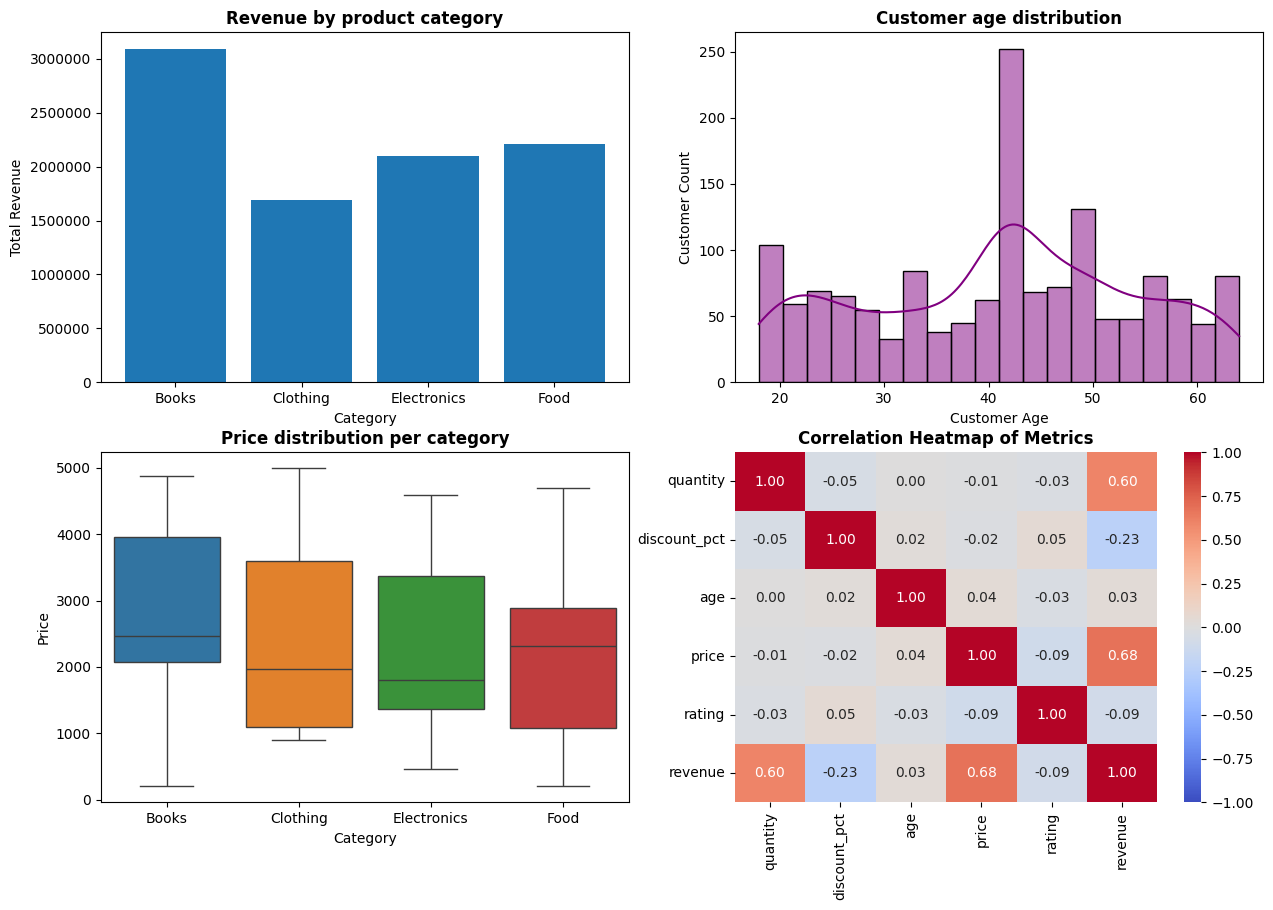

In [73]:
#Build at least 5 plots that together tell a coherent story about RetailSense's business.
fig, axes = plt.subplots(2,2, figsize=(15,10))
#Revenue by product category
rev_per_cate = full_df.groupby("category",observed=False)["revenue"].sum().reset_index()
axes[0,0].bar(rev_per_cate["category"], rev_per_cate["revenue"])
axes[0,0].set_xlabel("Category")
axes[0,0].set_ylabel("Total Revenue")
axes[0,0].set_title("Revenue by product category", fontweight="bold")
axes[0,0].ticklabel_format(style='plain', axis='y')
#Customer age distribution
sns.histplot(data=full_df, x="age", bins=20, kde=True, ax=axes[0,1], color="purple")
axes[0,1].set_xlabel("Customer Age")
axes[0,1].set_ylabel("Customer Count")
axes[0,1].set_title("Customer age distribution", fontweight="bold")

#Price distribution per category
sns.boxplot(data=full_df, x="category", y="price", hue="category", ax=axes[1,0])
axes[1,0].set_xlabel("Category")
axes[1,0].set_ylabel("Price")
axes[1,0].set_title("Price distribution per category", fontweight="bold")

#Correlation heatmap of numeric columns in full_df
num_df = full_df.select_dtypes(include=[np.number]).drop(columns=["order_id", "customer_id", "product_id"], errors="ignore")
corr_matrix = num_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1,1], vmax=1, vmin=-1)
axes[1, 1].set_title("Correlation Heatmap of Metrics", fontweight="bold")

#Interactive scatter: Price vs Rating (colored by category, hover shows product name)
fig = px.scatter(full_df, x="price", y="rating", color="category", size="price", hover_data="product_name", title="Price vs Rating ⬇️")
#fig.update_layout(height=600)
plt.show()
fig.show()

# 📋 RetailSense Business Dashboard Analytics Insights

## 1) P1: Revenue by Product Category (Matplotlib Bar Chart)
### -> Key Structural Properties:
* **X-Axis:** Product Category (Books, Clothing, Electronics, Food)
* **Y-Axis:** Total Revenue (Scale ranging up to 3,000,000+)

### -> One-Line Markdown Insight:
* **Insight:** Books serve as RetailSense's main financial engine by generating over 3 million in revenue, while Clothing underperforms as the lowest-earning business segment.

---

## 2) P2: Customer Age Distribution (Seaborn Histplot)
### -> Key Structural Properties:
* **X-Axis:** Customer Age (Ranging from roughly 18 to 64 years old)
* **Y-Axis:** Customer Count (Distribution density with a KDE trendline overlay)

### -> One-Line Markdown Insight:
* **Insight:** Customer acquisition relies heavily on a specific demographic cohort peaking sharply between 40 and 45 years old, with distinct volume drops in younger segments.

---

## 3) P3: Price Distribution per Category (Seaborn Boxplot)
### -> Key Structural Properties:
* **X-Axis:** Product Category
* **Y-Axis:** Unit Price (Distribution spreads ranging from 0 to 5,000)

### -> One-Line Markdown Insight:
* **Insight:** Books maintain the highest median price floor and tightest concentration, whereas Food represents our most budget-accessible tier with highly spread-out pricing variables.

---

## 4) P4: Correlation Heatmap of Metrics (Seaborn Heatmap)
### -> Key Structural Properties:
* **Matrix Scope:** 6x6 Matrix evaluating numeric variables (`quantity`, `discount_pct`, `age`, `price`, `rating`, `revenue`)
* **Color Scale:** Diverging `coolwarm` palette bounded strictly between -1.00 and 1.00

### -> One-Line Markdown Insight:
* **Insight:** Total revenue is heavily and positively driven by product price (0.68) and order quantity (0.60), whereas customer age and satisfaction ratings show zero statistical correlation to revenue outcomes.

---

## 5) P5: Interactive Scatter: Price vs Rating (Plotly Express Scatter)
### -> Key Structural Properties:
* **X-Axis:** Price ($)
* **Y-Axis:** Customer Rating
* **Interactive Tooltips:** `hover_name="product_name"`

### -> One-Line Markdown Insight:
* **Insight:** Evaluating the interactive data clusters exposes whether premium high-priced inventory successfully retains top customer satisfaction tiers across individual product lines.

#=================================================================


# API Integration ⬇️⬇️⬇️

In [74]:
# Test a Public API
print("="*60)
url = "https://jsonplaceholder.typicode.com/users"
response = requests.get(url)
print("Status Code:-",response.status_code)
resp_json = response.json()
print("="*60)
print("="*60)
user_data = []
for user in resp_json:
  user_id=user["id"]
  name=user["name"]
  email=user["email"]
  city=user["address"]["city"]
  user_data.append({"User ID":user_id, "Name":name, "Email":email, "City":city})
pprint.pprint(user_data)
print("="*60)

Status Code:- 200
[{'City': 'Gwenborough',
  'Email': 'Sincere@april.biz',
  'Name': 'Leanne Graham',
  'User ID': 1},
 {'City': 'Wisokyburgh',
  'Email': 'Shanna@melissa.tv',
  'Name': 'Ervin Howell',
  'User ID': 2},
 {'City': 'McKenziehaven',
  'Email': 'Nathan@yesenia.net',
  'Name': 'Clementine Bauch',
  'User ID': 3},
 {'City': 'South Elvis',
  'Email': 'Julianne.OConner@kory.org',
  'Name': 'Patricia Lebsack',
  'User ID': 4},
 {'City': 'Roscoeview',
  'Email': 'Lucio_Hettinger@annie.ca',
  'Name': 'Chelsey Dietrich',
  'User ID': 5},
 {'City': 'South Christy',
  'Email': 'Karley_Dach@jasper.info',
  'Name': 'Mrs. Dennis Schulist',
  'User ID': 6},
 {'City': 'Howemouth',
  'Email': 'Telly.Hoeger@billy.biz',
  'Name': 'Kurtis Weissnat',
  'User ID': 7},
 {'City': 'Aliyaview',
  'Email': 'Sherwood@rosamond.me',
  'Name': 'Nicholas Runolfsdottir V',
  'User ID': 8},
 {'City': 'Bartholomebury',
  'Email': 'Chaim_McDermott@dana.io',
  'Name': 'Glenna Reichert',
  'User ID': 9},
 {'Ci

In [75]:
#POST Request Practice
url="https://jsonplaceholder.typicode.com/posts"
data = {
  "title": "RetailSense Report",
  "body": "Q4 revenue exceeded targets by 12%",
  "userId": 1
}
response = requests.post(url, json=data)
if response.status_code==201:
  print("Request made SUccessfully:-",response.status_code)
else:
  print("Request Failed!!")
get_response = requests.get(url)
json_response = response.json()
print("ID:-",json_response["id"])

Request made SUccessfully:- 201
ID:- 101


In [76]:
#Save API Data to File
with open("outputs/api_users.json","w",encoding="utf-8") as f:
  json.dump(user_data,f,indent=2)

with open("outputs/api_users.json","r",encoding="utf-8") as f:
  json_data = json.load(f)

print("First user's name:", json_data[0]["Name"])

First user's name: Leanne Graham


#Ethics & Privacy Audit ⬇️⬇️⬇️

##Q1) List every column across your three datasets that qualifies as PII. For each, state whether you would drop it, hash it, or mask it before sharing the dataset externally — and why.
###Ans) Tables | Action | Reason
1) customer_id -> Hash -> They only need to track unique user behavior.
2) name -> Drop -> No need of name in analytics.
3) email -> mask -> Allows ad networks to match users securely without seeing raw text.
4) age -> Generalize -> Protects individual identity while keeping demographic trends.
5) city -> Hash -> Protecting ones location and also allowing it to be used in analytics.
6) gender -> Drop -> Hashing a binary/limited value is useless. Masking is not applicable.
7) order_id -> mask -> Replaces IDs with random tokens to allow order tracking while hiding internal database keys.
8) signup_date -> mask -> Converts specific dates into broader intervals (e.g., month/year) to hide specific user events while tracking growth trends.
9) order_date -> mask -> Changes exact times to broader buckets (e.g., month/year) to remove tracking precision while preserving temporal trends.
10) product_id -> mask Replaces specific item codes with generalized category tokens to hide exact buying choices while preserving volume data.

##Q2) If RetailSense wanted to share this dataset with a third-party ML vendor, what steps would you take to anonymize it? Be specific (which columns, which method).
###Ans)
1) customer_id -> drop
2) name -> drop
3) email -> hash
4) age -> generalize
5) city -> hash
6) gender -> drop
7) signup_date -> mask
8) order_id -> mask
9) product_id -> mask
10) order_date -> mask
11) quantity -> generalize
12) discount_pct -> generalize
13) product_name -> drop
14) category -> mask
15) price -> generalize
16) rating -> generalize

##Q3) The JSONPlaceholder API you used is for testing only. If you were using a real customer API (e.g., a CRM API), what three things would you check in its Terms of Service before using it in production?
###Ans) We will check the following things:-
1) Rate limit
2) Commercial use restrictions
3) Data licensing
4) AI/ML training restrictions
5) Storage or caching the data

##Q4) In Part 2, you filled null ages with the median. Could this choice introduce bias in your age_group analysis? Explain in 2–3 sentences.
###Ans) Yes this will introduce bias. his squashes the natural variance of the dataset and reduces the statistical significance of the younger and older cohorts. As a result, your age_group analysis will over-represent average-aged behaviors and mask the distinct purchasing trends of your outlier customers.